In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [3]:
station_ids = ['id-03','id-05']
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1735664400
1798736399


In [4]:
import pandas as pd

# Siapkan dictionary kosong untuk menampung DataFrame yang sudah bersih
all_weather_dataframes = {}

print("Memulai proses pengambilan dan pembersihan data dari Firebase...")
print("="*65)

for station in station_ids:
    try:
        # 1. TARIK DATA DARI FIREBASE
        ref_path = f'/auto_weather_stat/{station}/data'
        ref_data = db.reference(ref_path)
        query_data = ref_data.order_by_key().start_at(str(start_timestamp)).end_at(str(end_timestamp))
        results = query_data.get()
        
        if results:
            # 2. KONVERSI KE DATAFRAME
            df = pd.DataFrame.from_dict(results, orient='index')
            
            # Jika timestamp dari Firebase menjadi Index, turunkan menjadi kolom biasa
            if 'timestamp' not in df.columns:
                df.index.name = 'timestamp'
                df = df.reset_index()
            
            # 3. PENGECEKAN & PENCARIAN LOKASI NULL PADA TIMESTAMP
            null_mask = df['timestamp'].isnull()
            jumlah_null = null_mask.sum()
            
            if jumlah_null > 0:
                # Cari lokasi (nomor baris/index) di mana timestamp bernilai null
                lokasi_null = df[null_mask].index.tolist()
                print(f"   ⚠️ Peringatan: Ditemukan {jumlah_null} data NULL di stasiun {station}.")
                print(f"      -> Baris yang rusak: {lokasi_null}")
                
                # Buang baris yang timestamp-nya null agar tidak membuat error konversi selanjutnya
                df = df.dropna(subset=['timestamp'])
                print("      -> Data NULL telah dihapus.")

            # 4. UBAH TIMESTAMP MENJADI INTEGER
            # Kita ubah ke float dulu untuk jaga-jaga jika Firebase mengirimnya sebagai string '1710000000.0'
            df['timestamp'] = df['timestamp'].astype(float).astype(int)
            
            # 5. UBAH KE DATETIME UTC+7 (ASIA/BANGKOK ATAU ASIA/JAKARTA)
            # Karena timestamp Anda 10 digit, itu artinya formatnya adalah Detik (unit='s')
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
            
            # Konversi ke waktu lokal WIB (+07:00), lalu buang stempel zonanya agar aman untuk Machine Learning
            df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Bangkok')
            
            # Simpan DataFrame yang sudah sempurna ke dalam dictionary
            all_weather_dataframes[station] = df
            print(f"✅ Berhasil: Stasiun {station} siap! ({len(df)} baris data valid)")
            
        else:
            print(f"⚠️ Kosong: Tidak ada data untuk stasiun {station} pada rentang waktu ini.")
            
    except Exception as e:
        print(f"❌ Error: Gagal memproses data untuk {station}. Detail: {e}")

print("="*65)
print(f"Proses selesai. Data bersih tersedia untuk: {list(all_weather_dataframes.keys())}")

# Untuk melihat hasilnya:
# print(all_weather_dataframes['id-03'].head())
# print(all_weather_dataframes['id-03'].info())

Memulai proses pengambilan dan pembersihan data dari Firebase...
   ⚠️ Peringatan: Ditemukan 2 data NULL di stasiun id-03.
      -> Baris yang rusak: ['1757078040', '1766280720']
      -> Data NULL telah dihapus.
✅ Berhasil: Stasiun id-03 siap! (765698 baris data valid)
✅ Berhasil: Stasiun id-05 siap! (714427 baris data valid)
Proses selesai. Data bersih tersedia untuk: ['id-03', 'id-05']


In [62]:
import os

# 1. Tentukan nama folder target
output_folder = 'raw_data_sensor'

# Buat folder secara otomatis (jika sudah ada, Python tidak akan error berkat exist_ok=True)
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Direktori penyimpanan siap: '{output_folder}/'")
print("="*65)

# 2. Loop melalui dictionary yang berisi DataFrame bersih Anda
for station_id, df in all_weather_dataframes.items():
    try:
        # --- MENAMPILKAN DATA ---
        print(f"\n📊 Menampilkan 3 baris pertama untuk stasiun: {station_id}")
        print(df.head(3)) # Menampilkan sebagian kecil data agar layar tidak penuh
        
        # --- MENYIMPAN DATA KE CSV ---
        # Susun nama file yang rapi
        filename = f"raw_data_{station_id}.csv"
        file_path = os.path.join(output_folder, filename)
        
        # Eksekusi penyimpanan! 
        # Ingat: index=False wajib dipakai agar Pandas tidak membuat kolom angka urut tambahan
        df.to_csv(file_path, index=False)
        
        print(f"💾 Berhasil diekspor: {filename} ({len(df)} baris)")
        
    except Exception as e:
        print(f"❌ Gagal memproses atau menyimpan data untuk {station_id}. Detail: {e}")

print("\n" + "="*65)
print("🎉 SELURUH PROSES SELESAI! Silakan cek folder Anda di sebelah kiri layar.")

📁 Direktori penyimpanan siap: 'raw_data_sensor/'

📊 Menampilkan 3 baris pertama untuk stasiun: id-03
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   

   rainfall  rainrate  
0       NaN       NaN  
1       NaN       NaN  
2       NaN       NaN  
💾 Berhasil diekspor: raw_data_id-03.csv (765698 baris)

📊 Menampilkan 3 baris pertama untuk stasiun: id-05
        dew  humidity  pressure  rainfall  rainrate  temperature  \
0  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
2  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   

                  timestamp     volt  tips  rain_rate  
0 2025-03-19 13:41:37+07:00  4.20625   NaN        NaN  
1 

In [63]:
import os
import glob
import pandas as pd

# 1. Tentukan nama folder tempat data mentah Anda disimpan
folder_path = 'raw_data_sensor'

# Siapkan dictionary kosong untuk menampung DataFrame
all_weather_dataframes = {}

print(f"📂 Memulai proses pembacaan data dari folder '{folder_path}'...")
print("="*65)

# 2. Validasi apakah folder benar-benar ada di sistem
if not os.path.exists(folder_path):
    print(f"❌ Fatal Error: Folder '{folder_path}' tidak ditemukan di direktori saat ini!")
else:
    # 3. Cari semua file CSV di dalam folder menggunakan pola *.csv
    pola_pencarian = os.path.join(folder_path, '*.csv')
    daftar_file_csv = glob.glob(pola_pencarian)
    
    if len(daftar_file_csv) == 0:
        print(f"⚠️ Peringatan: Folder ditemukan, tetapi tidak ada file berekstensi .csv di dalamnya.")
    else:
        # 4. Loop untuk membaca setiap file yang ditemukan
        for file_path in daftar_file_csv:
            try:
                # Ambil nama file dari jalurnya (contoh: 'raw_data_sensor/weather_data_id-03.csv' -> 'weather_data_id-03.csv')
                nama_file = os.path.basename(file_path)
                
                # Ekstrak station_id dari nama file. 
                # Fungsi split('_')[-1] mengambil bagian terakhir setelah garis bawah, lalu kita hapus '.csv'-nya.
                station_id = nama_file.replace('.csv', '').split('_')[-1]
                
                # Eksekusi pembacaan data CSV
                df = pd.read_csv(file_path)
                
                # --- PENTING: KONVERSI ULANG WAKTU ---
                # Ingat! File CSV tidak bisa menyimpan tipe data "datetime". CSV hanya menyimpan teks biasa (string).
                # Jadi, kita wajib mengubah kolom teks tersebut kembali menjadi wujud Datetime Pandas.
                if 'timestamp' in df.columns:
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                    
                    # (Opsional) Jika Anda ingin timestamp langsung menjadi index lagi seperti sebelumnya:
                    # df = df.set_index('timestamp')
                elif df.index.name == 'timestamp':
                    # Jika timestamp kebetulan tersimpan sebagai index
                    df.index = pd.to_datetime(df.index)

                # Masukkan kembali ke dalam pelukan dictionary kita
                all_weather_dataframes[station_id] = df
                
                print(f"✅ Berhasil memuat: {nama_file} -> Stasiun '{station_id}' ({len(df)} baris data)")
                
            except Exception as e:
                print(f"❌ Gagal membaca file '{nama_file}'. Detail Error: {e}")

print("="*65)
print(f"Proses Muat Data Selesai! Data siap dilanjutkan ke tahap Reindexing dan Filtering.")

# Untuk memvalidasi hasilnya, Anda bisa melakukan print seperti biasa:
# print(all_weather_dataframes['id-03'].info())

📂 Memulai proses pembacaan data dari folder 'raw_data_sensor'...
✅ Berhasil memuat: raw_data_id-03.csv -> Stasiun 'id-03' (765698 baris data)
✅ Berhasil memuat: raw_data_id-05.csv -> Stasiun 'id-05' (714427 baris data)
Proses Muat Data Selesai! Data siap dilanjutkan ke tahap Reindexing dan Filtering.


🔍 MEMULAI INSPEKSI MISSING VALUES KE SEMUA STASIUN...
📊 REPORT STASIUN: ID-03

=== 1. Jumlah Missing Values ===
dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       732012
rainrate       732012
dtype: int64

=== 2. Persentase Missing Values ===
dew             0.00%
humidity        0.00%
pressure        0.00%
temperature     0.00%
timestamp       0.00%
volt            0.00%
rainfall       95.60%
rainrate       95.60%
dtype: object

=== 3. Inspeksi Baris Null ===
Jumlah baris kotor (mengandung minimal 1 NaN): 732012 baris dari total 765698 baris.

Contoh 5 baris yang mengandung null:
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   
3  24.73

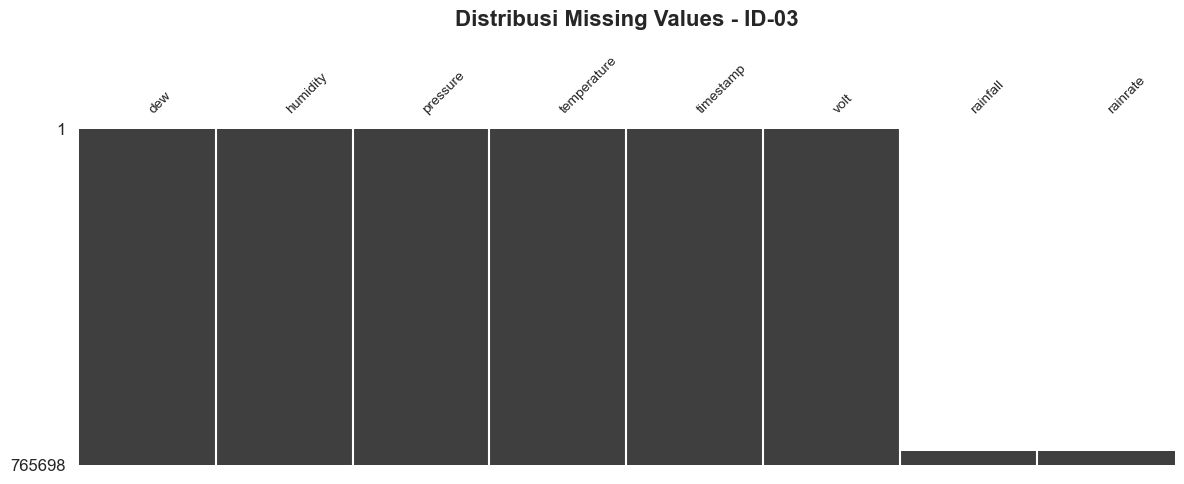

📊 REPORT STASIUN: ID-05

=== 1. Jumlah Missing Values ===
dew                 0
humidity            0
pressure            0
rainfall           71
rainrate           71
temperature         0
timestamp           0
volt              277
tips           595374
rain_rate      712994
dtype: int64

=== 2. Persentase Missing Values ===
dew             0.00%
humidity        0.00%
pressure        0.00%
rainfall        0.01%
rainrate        0.01%
temperature     0.00%
timestamp       0.00%
volt            0.04%
tips           83.34%
rain_rate      99.80%
dtype: object

=== 3. Inspeksi Baris Null ===
Jumlah baris kotor (mengandung minimal 1 NaN): 712994 baris dari total 714427 baris.

Contoh 5 baris yang mengandung null:
        dew  humidity  pressure  rainfall  rainrate  temperature  \
0  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
2  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   
3  27.6826

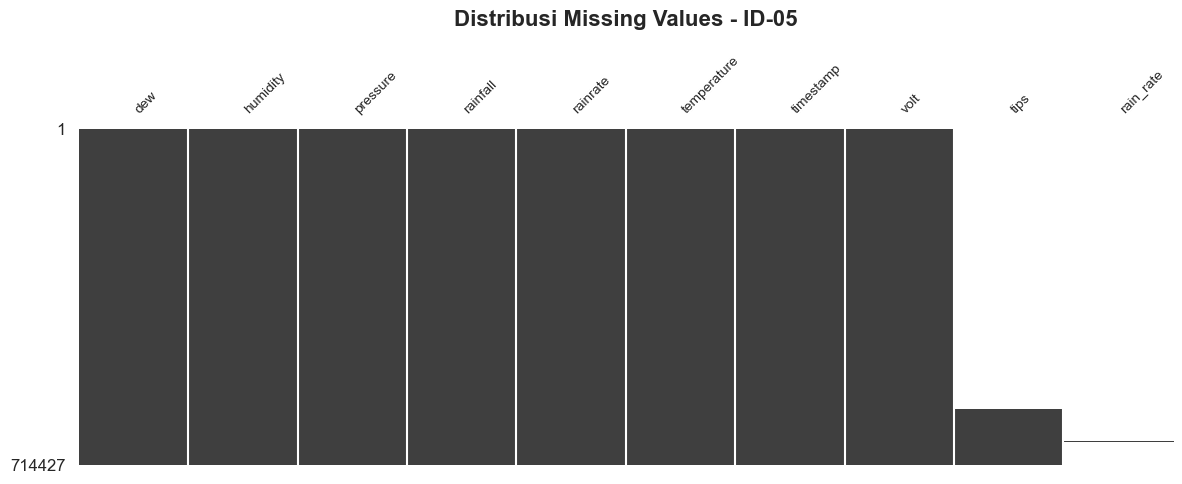


🏁 SELURUH INSPEKSI SELESAI!


In [64]:
import missingno as msno
import matplotlib.pyplot as plt

print("🔍 MEMULAI INSPEKSI MISSING VALUES KE SEMUA STASIUN...")

# Looping melalui setiap stasiun (key) dan tabel datanya (value)
for station_id, df in all_weather_dataframes.items():
    
    print(f"📊 REPORT STASIUN: {station_id.upper()}")
    
    # Cek apakah DataFrame kosong
    if df.empty:
        print(f"⚠️ Peringatan: Data untuk stasiun {station_id} kosong!")
        continue

    # 1. Mengecek nilai null dalam DataFrame stasiun saat ini
    print("\n=== 1. Jumlah Missing Values ===")
    print(df.isnull().sum())
    
    # 2. Menampilkan persentase missing values
    print("\n=== 2. Persentase Missing Values ===")
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    # Memformat output menjadi string dengan 2 angka di belakang koma plus tanda '%'
    print(missing_percentage.apply(lambda x: f"{x:.2f}%"))
    
    # 3. Menampilkan baris-baris yang mengandung nilai null
    print("\n=== 3. Inspeksi Baris Null ===")
    null_rows = df[df.isnull().any(axis=1)]
    print(f"Jumlah baris kotor (mengandung minimal 1 NaN): {len(null_rows)} baris dari total {len(df)} baris.")
    
    if len(null_rows) > 0:
        print("\nContoh 5 baris yang mengandung null:")
        print(null_rows.head(5))
    else:
        print("✅ LUAR BIASA! Tabel ini 100% bersih tanpa ada data yang bolong.")

    # 4. Visualisasi missing values menggunakan missingno
    print(f"\n=== 4. Peta Visual Missing Values ({station_id}) ===")
    
    # Membuat figure Matplotlib secara eksplisit agar judul bisa disisipkan dengan rapi
    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(111)
    
    # Memanggil missingno matrix ke dalam axes yang sudah kita buat
    msno.matrix(df, ax=ax, sparkline=False, fontsize=10)
    
    # Menambahkan judul spesifik per stasiun
    ax.set_title(f"Distribusi Missing Values - {station_id.upper()}", fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("🏁 SELURUH INSPEKSI SELESAI!")

In [98]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.
    """
    # 1. Konfigurasi Label Frekuensi (KODE DIPERBAIKI KE STANDAR PANDAS BARU)
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'd'}, 
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'h'},
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'min'}
    }
    
    selected_freq = freq_config.get(freq, freq_config['d'])
    
    # 2. Konfigurasi Label Agregasi
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))
    plot_berhasil = False # Penanda apakah ada yang berhasil di-plot

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"⚠️ Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()
        
        # --- PERBAIKAN 1: Pastikan timestamp bisa diakses ---
        if 'timestamp' not in temp_df.columns and temp_df.index.name == 'timestamp':
            temp_df = temp_df.reset_index()

        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # --- PERBAIKAN 2: Paksa kolom target menjadi numerik murni ---
        # Jika Firebase mengirim string "28", ini akan memaksanya jadi float 28.0
        temp_df[column_to_plot] = pd.to_numeric(temp_df[column_to_plot], errors='coerce')

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        time_col = f'time_group_{freq}'
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
        
        # Lakukan agregasi. Dropna() mencegah eror jika ada data kosong.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).dropna().reset_index()

        # Jika setelah agregasi datanya kosong, lewati
        if trend_data.empty:
            print(f"⚠️ Peringatan: Data agregasi untuk {station_id} kosong.")
            continue

        # --- PERBAIKAN 3: Tambahkan marker='o' ---
        # Ini memastikan jika datanya hanya 1 titik, titik tersebut akan tetap terlihat!
        plt.plot(
            trend_data[time_col], 
            trend_data[column_to_plot], 
            label=station_id, 
            alpha=0.8, 
            )
        plot_berhasil = True

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')
    
    if plot_berhasil:
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'TIDAK ADA DATA VALID UNTUK DITAMPILKAN', 
                 ha='center', va='center', fontsize=16, color='red', transform=plt.gca().transAxes)
        
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# CARA PEMANGGILAN:
# plot_station_trends(all_weather_dataframes, 'temperature', freq='h', agg_method='max')

Menampilkan plot perbandingan per jam...


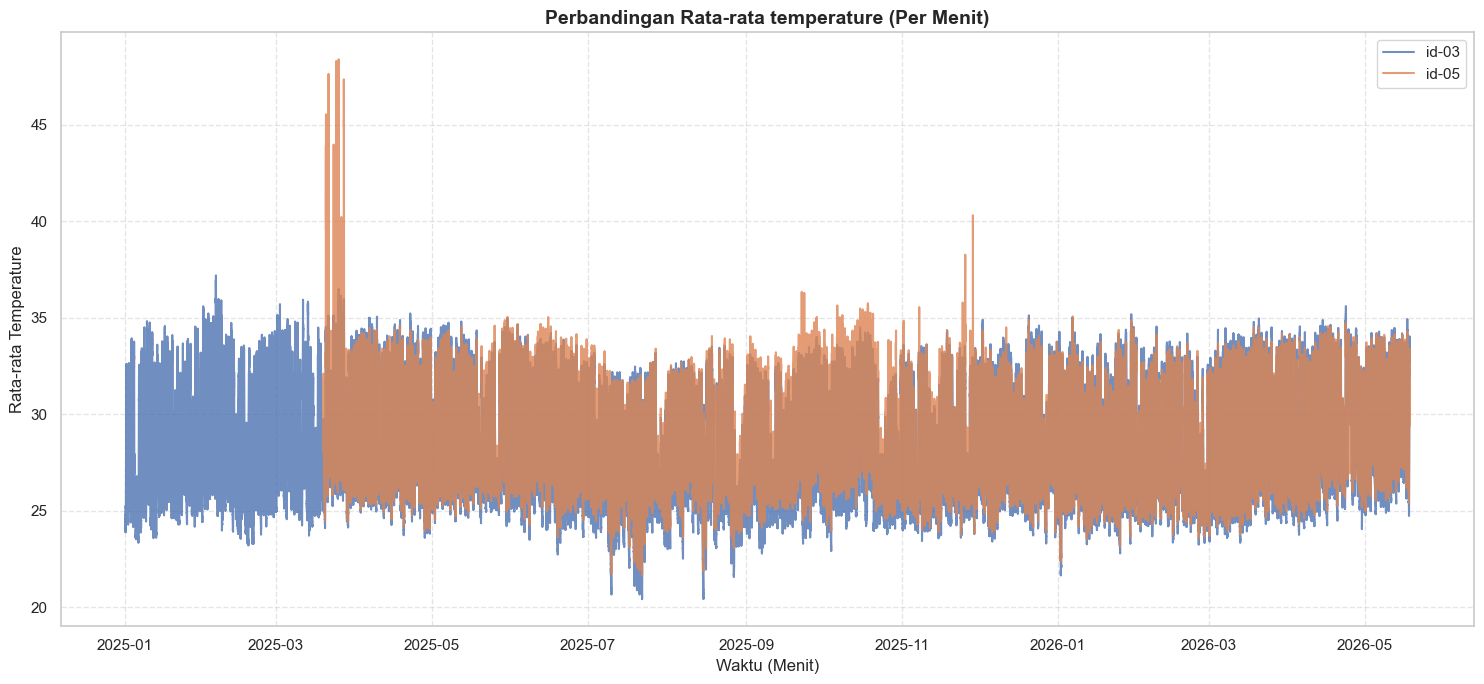

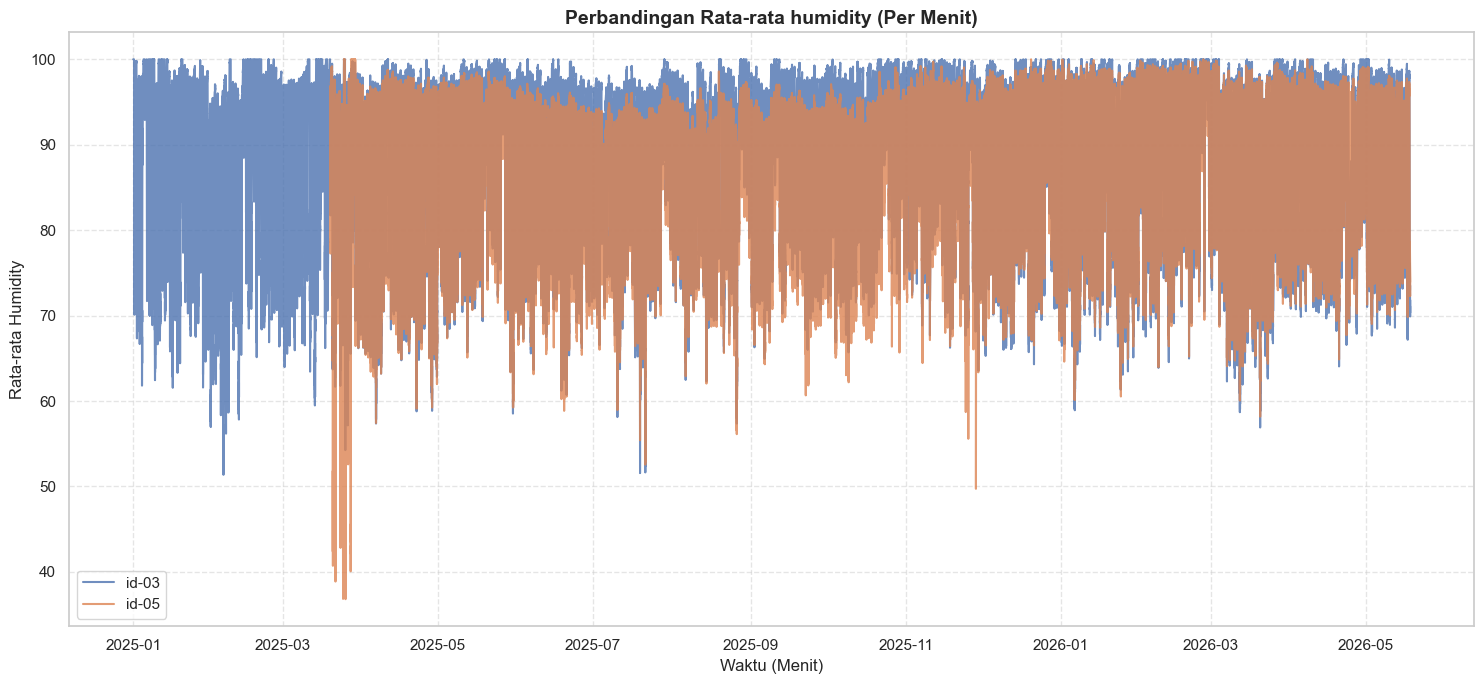

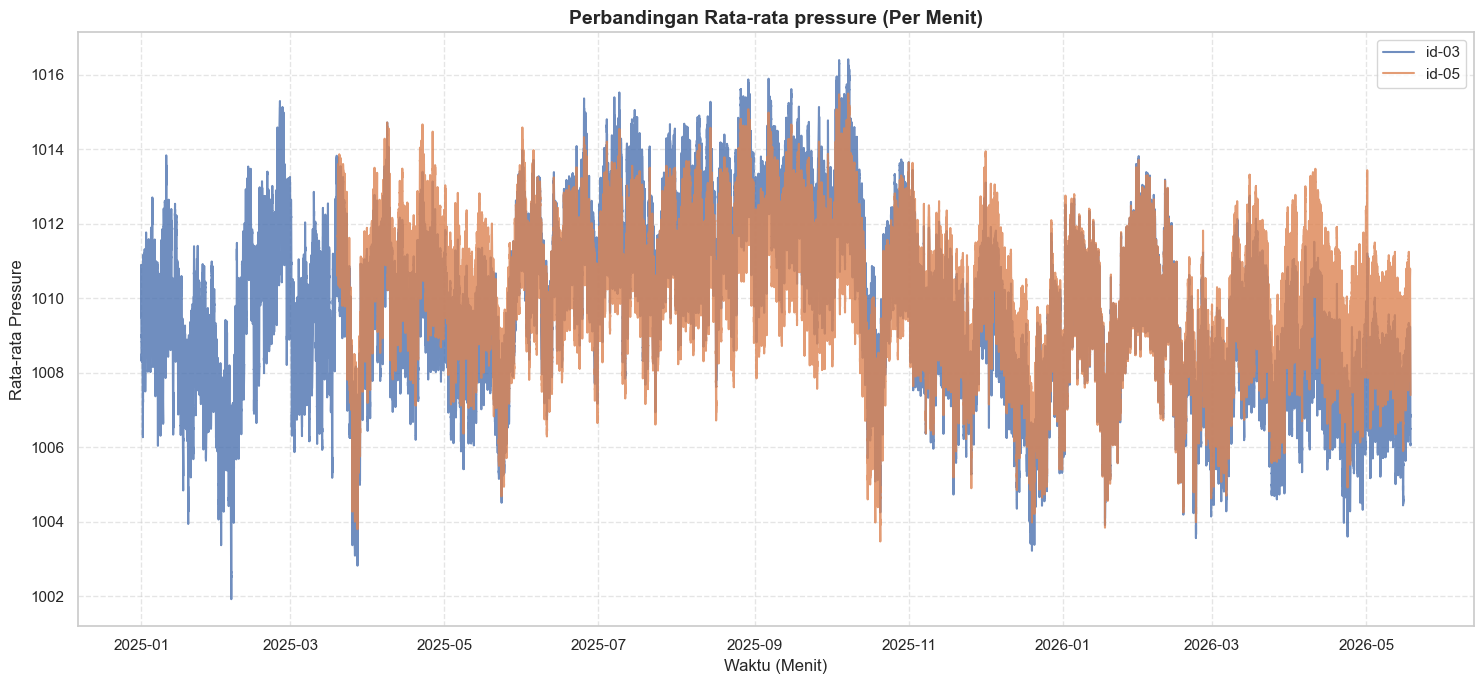

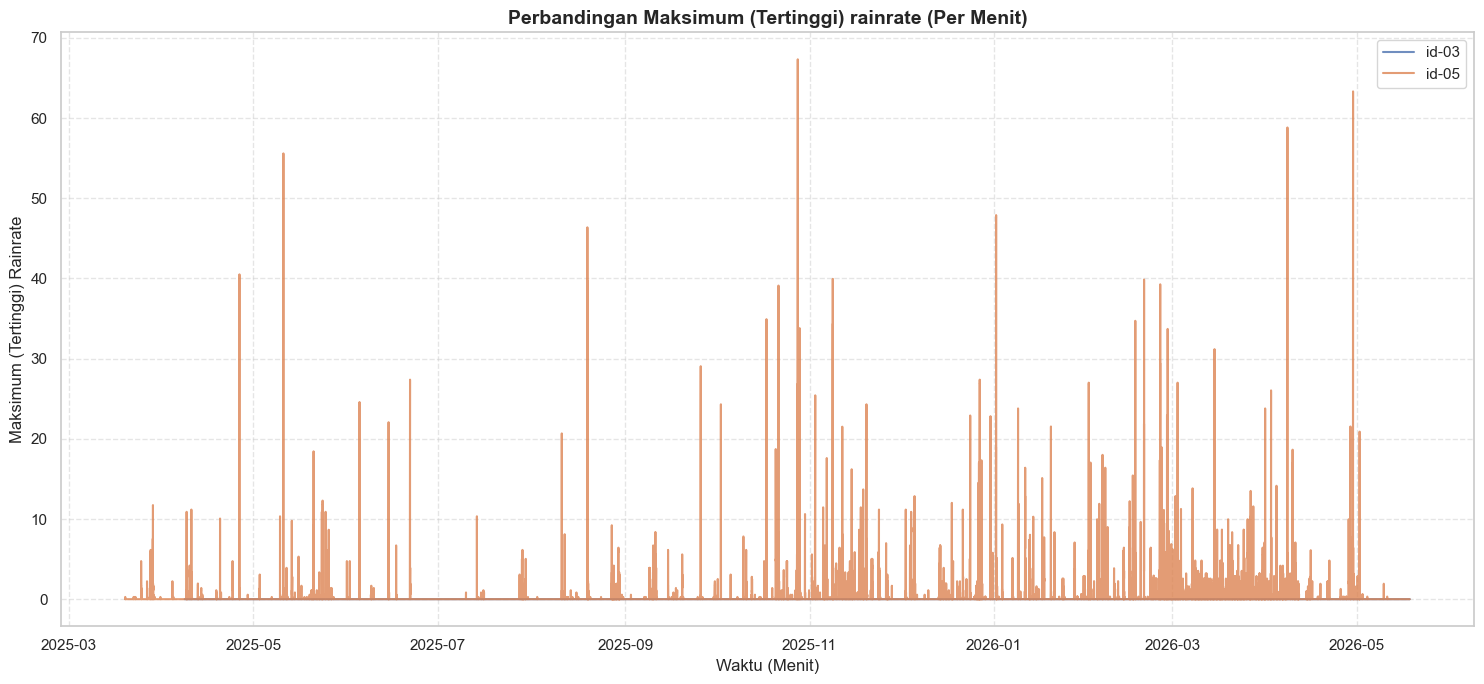

In [66]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'rainrate', freq='min', agg_method='max')


Menampilkan plot perbandingan per hari...


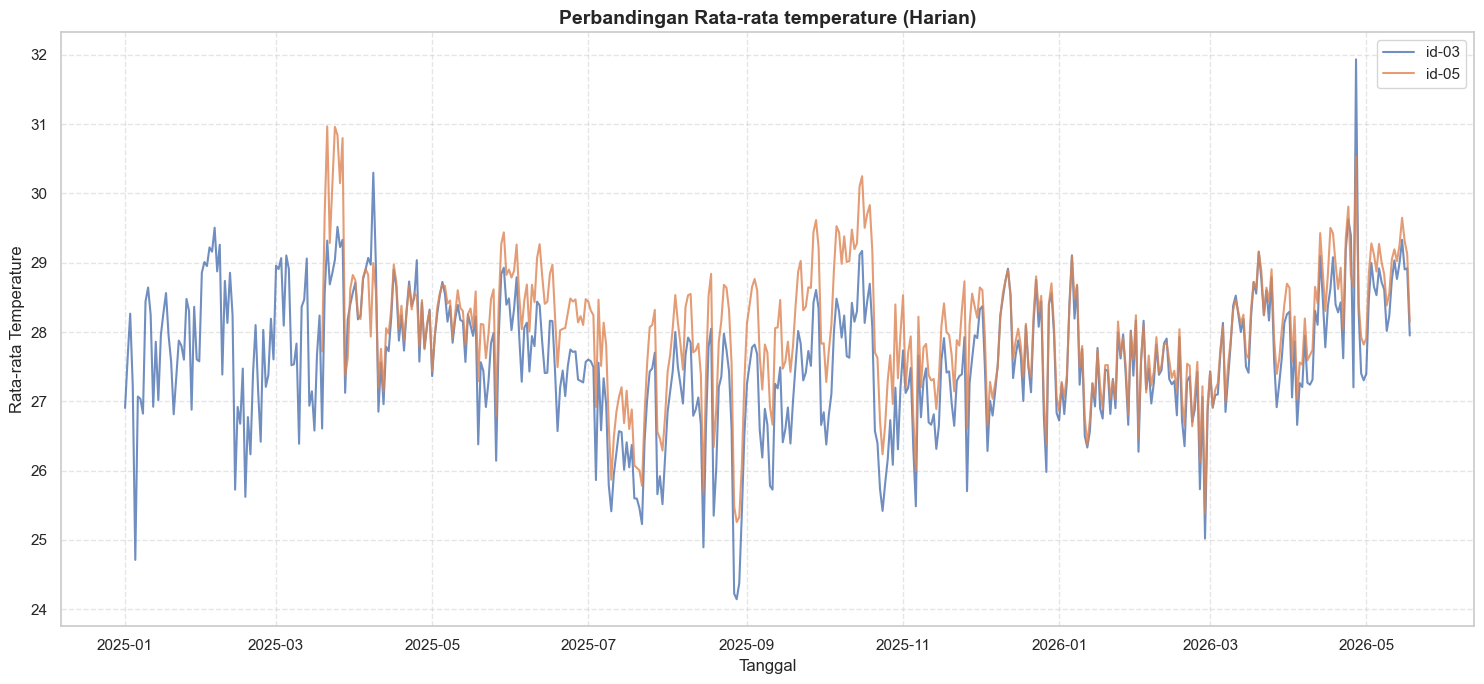

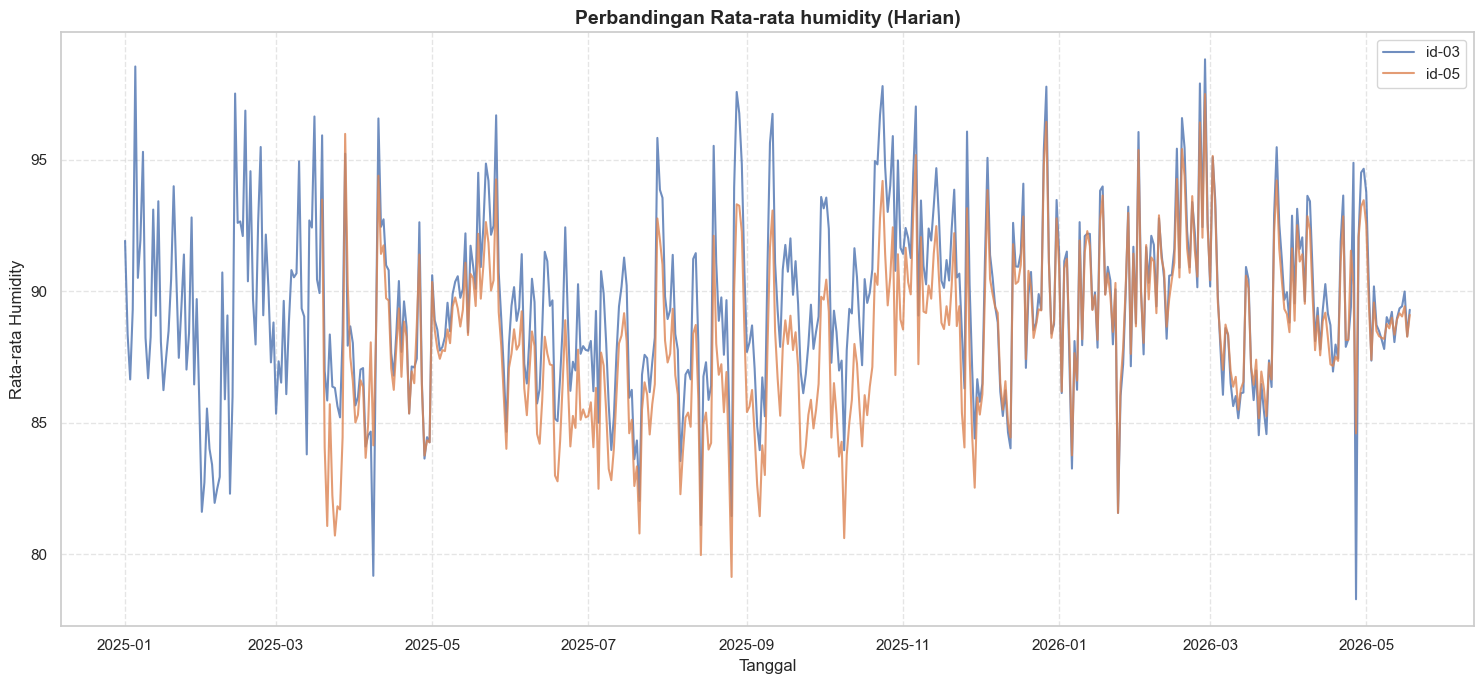

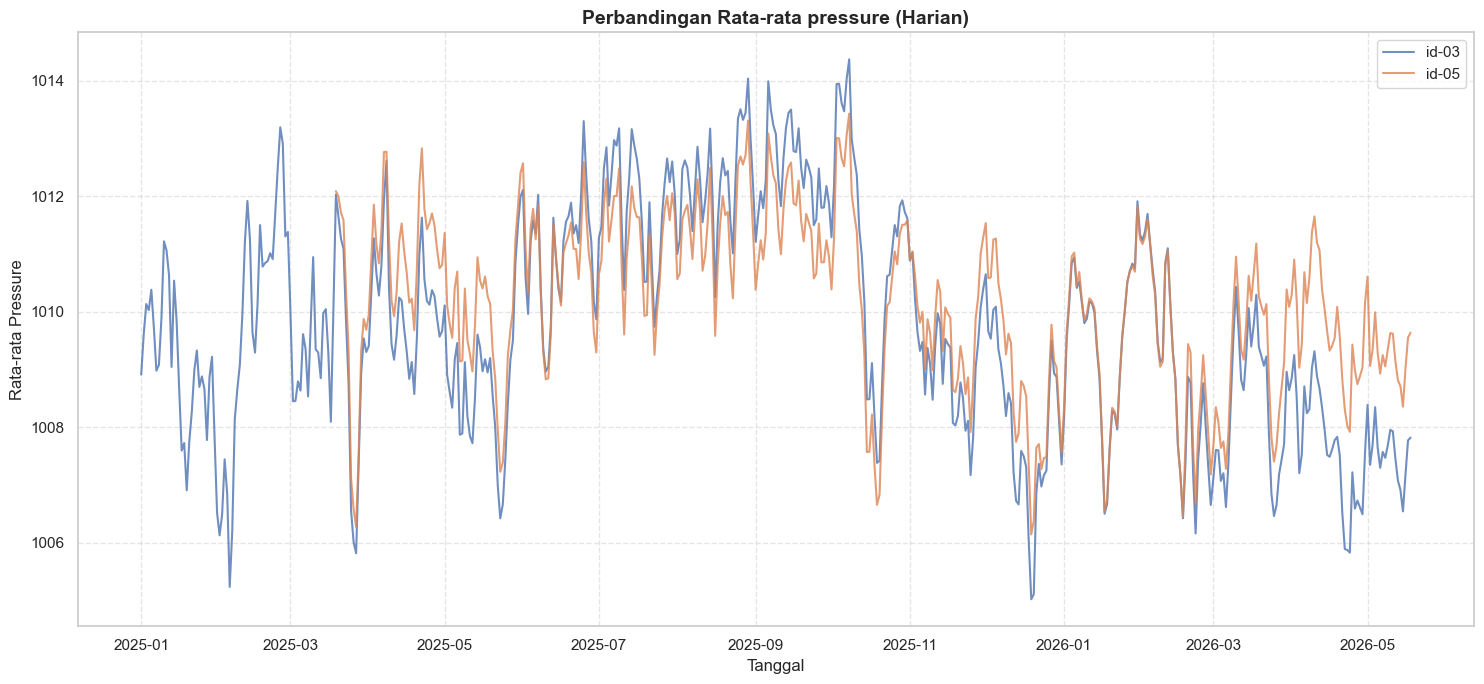

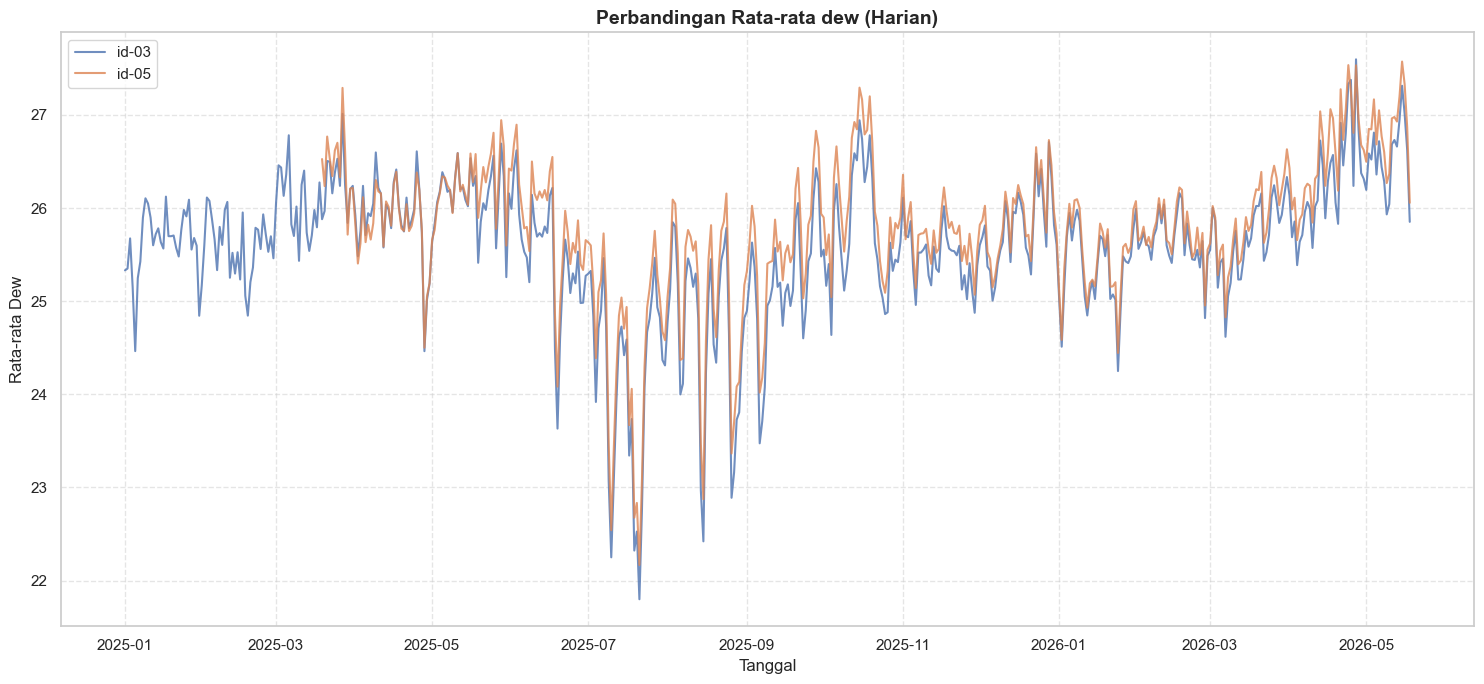

In [67]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'dew', freq='d', agg_method='mean')

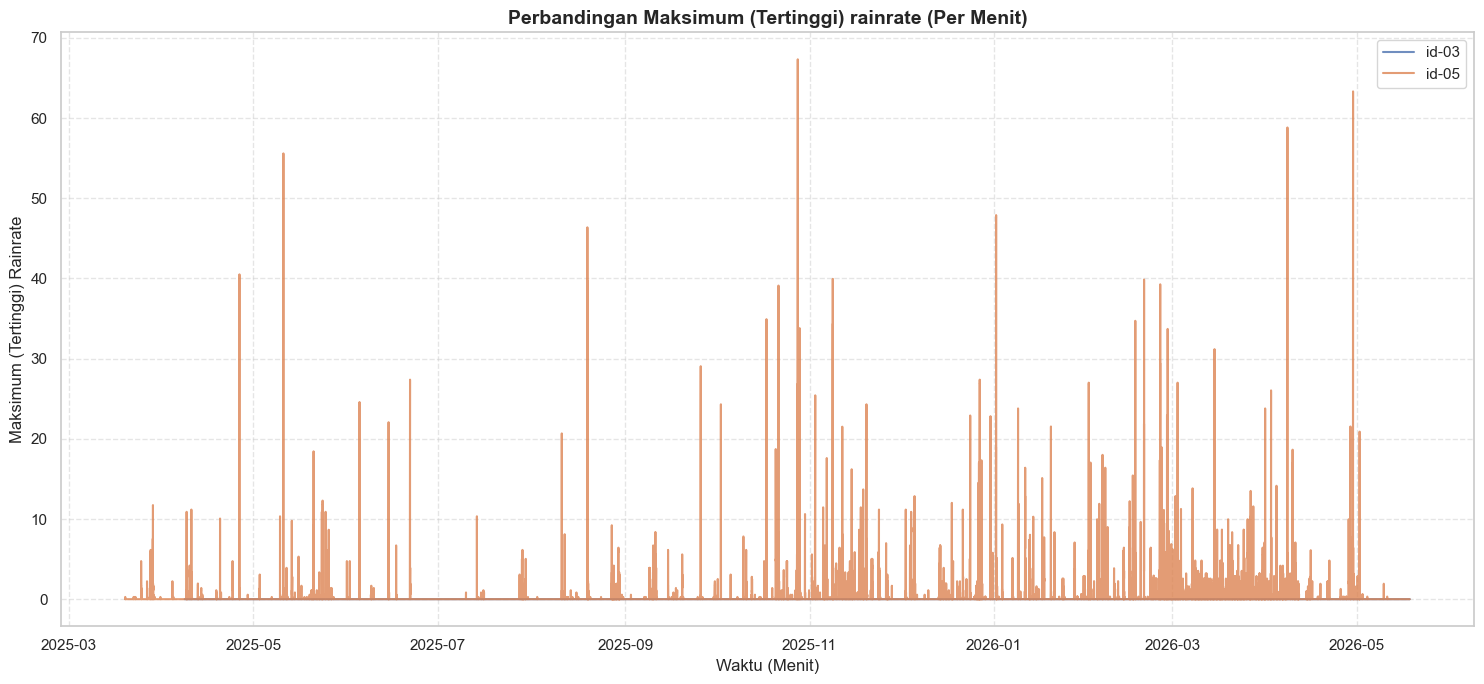

In [68]:
plot_station_trends(all_weather_dataframes, 'rainrate', freq='min', agg_method='max')

In [69]:
cuaca5 = all_weather_dataframes['id-05']

In [70]:
cuaca5.tail(20)

,dew,humidity,pressure,rainfall,rainrate,temperature,timestamp,volt,tips,rain_rate
714407,27.87807,73.86382,1007.64,0.0,0.0,33.18723,2026-05-18 12:51:28+07:00,3.87750,0.0,NaN
714408,27.59694,72.55535,1007.63,0.0,0.0,33.21393,2026-05-18 12:52:28+07:00,3.88875,0.0,NaN
714409,27.67258,72.91966,1007.61,0.0,0.0,33.20325,2026-05-18 12:53:28+07:00,3.87875,0.0,NaN
714410,27.79321,73.12756,1007.62,0.0,0.0,33.27802,2026-05-18 12:54:28+07:00,3.86375,0.0,NaN
714411,27.74383,72.95018,1007.58,0.0,0.0,33.27001,2026-05-18 12:55:28+07:00,3.88375,0.0,NaN
714412,27.67530,72.82238,1007.57,0.0,0.0,33.22995,2026-05-18 12:56:28+07:00,3.88250,0.0,NaN
714413,27.80106,73.18288,1007.55,0.0,0.0,33.27268,2026-05-18 12:57:28+07:00,3.87875,0.0,NaN
714414,27.94677,73.65209,1007.50,0.0,0.0,33.31006,2026-05-18 12:58:28+07:00,3.88250,0.0,NaN
714415,27.89569,73.32402,1007.53,0.0,0.0,33.33677,2026-05-18 12:59:28+07:00,3.86125,0.0,NaN
714416,27.66286,72.63927,1007.52,0.0,0.0,33.26200,2026-05-18 13:00:28+07:00,3.88375,0.0,NaN


In [71]:
import pandas as pd
import numpy as np

# =======================================================
# 1. PERSIAPAN DATA WAKTU (PENTING!)
# =======================================================
# Kita gunakan IF agar aman. Jika kolom 'timestamp' masih ada, 
# kita jadikan dia DatetimeIndex. Jika sudah jadi index, kode ini diabaikan.
if 'timestamp' in cuaca5.columns:
    cuaca5['timestamp'] = pd.to_datetime(cuaca5['timestamp'])
    cuaca5 = cuaca5.sort_values('timestamp').set_index('timestamp')

# =======================================================
# 2. DETEKSI INCREMENT & PENANGANAN RESET ALAT
# =======================================================
# Hitung selisih hujan dari menit ke menit
cuaca5['delta_raw'] = cuaca5['rainrate'].diff()

# Jika negatif (reset), ambil nilai aslinya. Jika positif, ambil selisihnya.
cuaca5['actual_increment'] = np.where(
    cuaca5['delta_raw'] < 0, 
    cuaca5['rainrate'],      
    cuaca5['delta_raw']      
)
cuaca5['actual_increment'] = cuaca5['actual_increment'].fillna(0).clip(lower=0)

# =======================================================
# 3. FILTER OUTLIER (HARD PHYSICAL THRESHOLD)
# =======================================================
BATAS_MAKSIMAL_PER_MENIT = 3.0  # Konservatif untuk menghindari false positive

# Cari indeks mana yang tidak wajar
kondisi_outlier = cuaca5['actual_increment'] > BATAS_MAKSIMAL_PER_MENIT
jumlah_outlier = kondisi_outlier.sum()

print(f"🚨 Terdeteksi {jumlah_outlier} titik outlier (goyangan palsu / lonjakan tak wajar)!")

# HANCURKAN OUTLIER
cuaca5.loc[kondisi_outlier, 'actual_increment'] = 0.0

# =======================================================
# 4. PEMBULATAN TIP (STANDARISASI KE 0.3)
# =======================================================
KONSTANTA_TIP = 0.3
cuaca5['tips_count'] = np.round(cuaca5['actual_increment'] / KONSTANTA_TIP)
cuaca5['increment_fixed'] = cuaca5['tips_count'] * KONSTANTA_TIP

# =======================================================
# 5. REKONSTRUKSI AKUMULASI PER JAM
# =======================================================
# [DIPERBAIKI] Gunakan 'rainrate_fixed' agar data asli 'rainrate' tidak hilang!
# [DIPERBAIKI] Gunakan 'H' besar.
cuaca5['rainrate'] = cuaca5.groupby(cuaca5.index.floor('h'))['increment_fixed'].cumsum()

# =======================================================
# 6. AGREGASI HARIAN / PER JAM
# =======================================================
# [DIPERBAIKI] Resample menggunakan 'H' besar dan ambil kolom 'rainrate'
df_hourly = cuaca5.resample('h').agg({
    'rainrate': 'max',  # Mengambil nilai puncak akumulasi di jam tersebut
    'temperature': 'mean',    
    'humidity': 'mean',       
    'pressure': 'mean',       
    'dew': 'mean'             
})

# Tampilkan hasil
print("✅ Pembersihan dan Agregasi Selesai!")
print(df_hourly.head(10))

🚨 Terdeteksi 128 titik outlier (goyangan palsu / lonjakan tak wajar)!
✅ Pembersihan dan Agregasi Selesai!
                           rainrate  temperature   humidity     pressure  \
timestamp                                                                  
2025-03-19 13:00:00+07:00       0.0    28.163365  94.335827  1011.120959   
2025-03-19 14:00:00+07:00       0.3    29.084335  91.649419  1010.880125   
2025-03-19 15:00:00+07:00       0.0    30.934129  83.867371  1010.835198   
2025-03-19 16:00:00+07:00       0.0    30.897955  83.783592  1010.911521   
2025-03-19 17:00:00+07:00       0.0    28.565734  90.632079  1011.434678   
2025-03-19 18:00:00+07:00       0.0    27.037647  94.918693  1011.847287   
2025-03-19 19:00:00+07:00       0.0    26.603566  96.829447  1012.464685   
2025-03-19 20:00:00+07:00       0.0    26.311772  97.622218  1013.006779   
2025-03-19 21:00:00+07:00       0.0    26.173208  98.185907  1013.179163   
2025-03-19 22:00:00+07:00       0.0    25.865855  98.24067

C:\Users\acer\AppData\Local\Temp\ipykernel_22596\2650539322.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


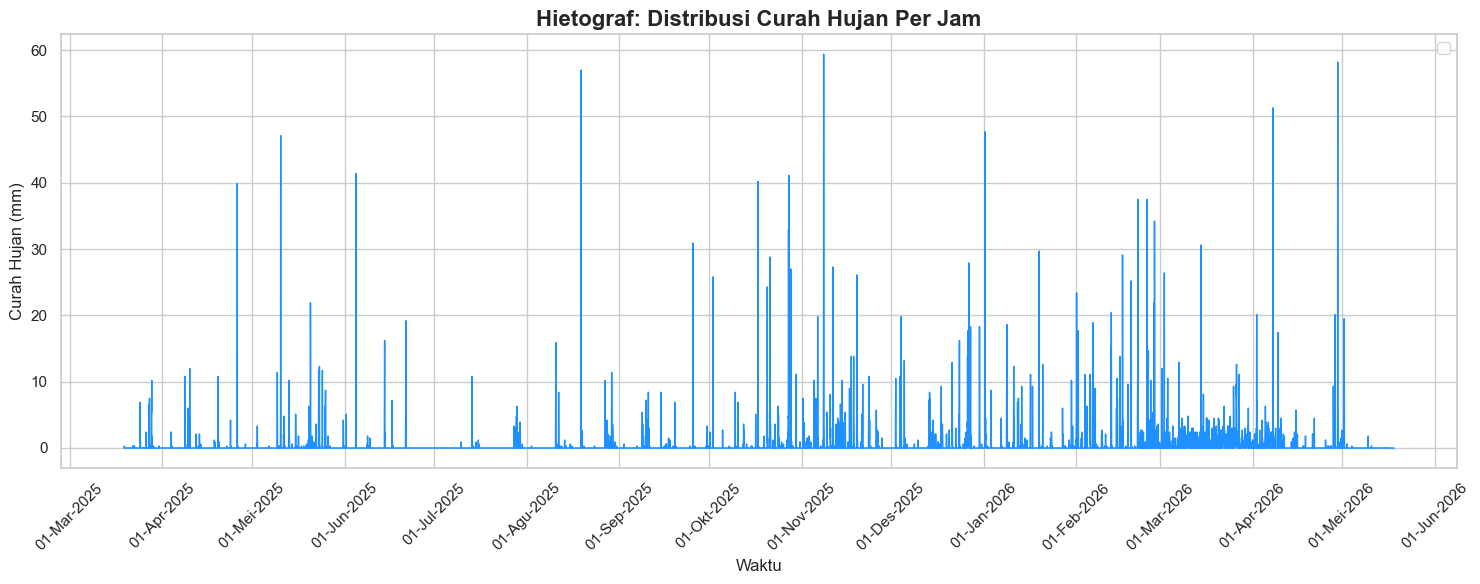

In [ ]:
# Set Style biar ganteng
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain_mm'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [ ]:
df_hourly.tail(50)

,rainrate,temperature,humidity,pressure,dew
timestamp,,,,,
2026-04-27 18:00:00+07:00,0.0,29.151217,90.850803,1008.176735,27.496635
2026-04-27 19:00:00+07:00,0.0,28.862473,92.593098,1009.226102,27.536981
2026-04-27 20:00:00+07:00,0.0,28.678808,93.336686,1009.934576,27.492164
2026-04-27 21:00:00+07:00,0.0,28.167545,93.946499,1010.124500,27.096496
2026-04-27 22:00:00+07:00,0.0,27.752930,94.920564,1009.901167,26.861031
...,...,...,...,...,...
2026-05-18 09:00:00+07:00,0.0,30.384185,80.056625,1010.404333,26.538908
2026-05-18 10:00:00+07:00,0.0,31.900310,74.857006,1009.651356,26.864766
2026-05-18 11:00:00+07:00,0.0,32.099159,76.016321,1008.834333,27.320947


In [ ]:
# ==============================================================================
# 0. PERSIAPAN DATA ERA5 (OPEN-METEO)
# ==============================================================================
era5_path = r'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv'

print("🌍 Memuat Data ERA5...")
df_era5 = pd.read_csv(era5_path)

# Asumsi kolom waktu di Open-Meteo sekarang bernama 'date'
time_col_era5 = 'date' if 'date' in df_era5.columns else 'timestamp'
df_era5[time_col_era5] = pd.to_datetime(df_era5[time_col_era5])
df_era5 = df_era5.set_index(time_col_era5)

# PERBAIKAN ZONA WAKTU ERA5: JANGAN DIBUANG! Tetap pertahankan di Asia/Bangkok
if df_era5.index.tz is None:
    # Jika ERA5 masih polos (biasanya Open-Meteo aslinya UTC), kita tetapkan UTC lalu konversi ke WIB
    df_era5.index = df_era5.index.tz_localize('UTC').tz_convert('Asia/Bangkok')
else:
    # Jika sudah punya zona waktu, langsung konversi saja ke WIB
    df_era5.index = df_era5.index.tz_convert('Asia/Bangkok')

# Mapping nama kolom Open-Meteo ke nama kolom IoT kita
era5_mapping = {
    'temperature': 'temperature_era5', 
    'humidity': 'humidity_era5',
    'pressure': 'sealevel_pressure_era5',
    'dew': 'dewpoint_era5',
    'rainrate': 'rain_mm',
}
print(f"✅ ERA5 Siap! Dimensi: {df_era5.shape} (Zona Waktu: {df_era5.index.tz})")
print("="*65)

# ==============================================================================
# 1. FUNGSI PIPELINE: REINDEXING MUTLAK + HAMPEL + IMPUTASI HIBRIDA
# ==============================================================================
def bersihkan_data_hourly(df_hourly, df_era5_reference, start_time, end_time):
    """
    Melakukan Reindexing MUTLAK (berdasarkan input user), Hampel Filter, 
    Imputasi Spline untuk lubang kecil, dan Substitusi ERA5 untuk lubang besar.
    """
    print(f"⚙️ Memulai Pipeline Hibrida | Rentang: {start_time} s.d {end_time}")
    
    # --- PENGAMANAN ZONA WAKTU IoT ---
    # Pastikan df_hourly juga memiliki zona waktu Asia/Bangkok agar reindex tidak error/NaN semua
    if df_hourly.index.tz is None:
        df_hourly.index = df_hourly.index.tz_localize('Asia/Bangkok')
    else:
        df_hourly.index = df_hourly.index.tz_convert('Asia/Bangkok')
    
    # --- TAHAP 1: REINDEXING MUTLAK ---
    # Master index kita set eksplisit menggunakan Asia/Bangkok
    master_index = pd.date_range(start=start_time, end=end_time, freq='h', tz='Asia/Bangkok') 
    
    df_reindexed = df_hourly.reindex(master_index)
    df_reindexed.index.name = 'timestamp'
    
    # Simpan versi mentah untuk perbandingan plot
    df_raw = df_reindexed.copy()
    
    # --- TAHAP 2: HAMPEL FILTER & IMPUTASI HIBRIDA ---
    kolom_sensor = ['temperature', 'humidity', 'pressure', 'dew']
    window = 12
    n_sigmas = 3
    
    for col in kolom_sensor:
        if col in df_reindexed.columns:
            # 1. Deteksi Outlier dengan Hampel Filter
            rolling_median = df_reindexed[col].rolling(window=window, center=True).median()
            deviasi = np.abs(df_reindexed[col] - rolling_median)
            mad = deviasi.rolling(window=window, center=True).median()
            threshold = n_sigmas * 1.4826 * mad
            outlier_idx = deviasi > threshold
            
            # Hancurkan outlier (jadikan NaN)
            df_reindexed.loc[outlier_idx, col] = np.nan
            
            # 2. Imputasi PCHIP (HANYA UNTUK LUBANG KECIL MAKSIMAL 4 JAM)
            df_reindexed[col] = df_reindexed[col].interpolate(
                method='pchip', 
                limit=4,  
                limit_direction='forward'
            )
            
            # 3. SUBSTITUSI ERA5 (UNTUK SISA LUBANG RAKSASA)
            nama_kolom_era5 = era5_mapping.get(col)
            if nama_kolom_era5 and nama_kolom_era5 in df_era5_reference.columns:
                # Tambal NaN yang tersisa di IoT menggunakan data dari ERA5
                df_reindexed[col] = df_reindexed[col].fillna(df_era5_reference[nama_kolom_era5])

            # Tambalan darurat terakhir jika ERA5 bolong di ujung (jarang terjadi)
            df_reindexed[col] = df_reindexed[col].bfill().ffill()

    # --- TAHAP 3: PENANGANAN KHUSUS HUJAN (ASIMILASI ERA5) ---
    kolom_hujan = ['rain_mm', 'rainfall', 'rainrate']
    for col in kolom_hujan:
        if col in df_reindexed.columns:
            # 1. Coba tambal lubang hujan IoT menggunakan data ERA5 terlebih dahulu!
            nama_kolom_era5 = era5_mapping.get(col)
            if nama_kolom_era5 and nama_kolom_era5 in df_era5_reference.columns:
                df_reindexed[col] = df_reindexed[col].fillna(df_era5_reference[nama_kolom_era5])
            
            # 2. Jika di ERA5 ternyata masih bolong juga (jarang terjadi), baru jadikan 0
            df_reindexed[col] = df_reindexed[col].fillna(0.0)

    print("✅ Pipeline Selesai! Data sudah Terstandarisasi Mutlak (PCHIP + ERA5).")
    return df_raw, df_reindexed

# ==============================================================================
# 2. FUNGSI VISUALISASI SEBELUM VS SESUDAH
# ==============================================================================
def plot_sebelum_sesudah(df_raw, df_clean, nama_kolom, satuan, start_time=None, end_time=None):
    if start_time and end_time:
        df_raw_plot = df_raw.loc[start_time:end_time]
        df_clean_plot = df_clean.loc[start_time:end_time]
        judul_waktu = f"({start_time} s.d {end_time})"
    else:
        df_raw_plot = df_raw
        df_clean_plot = df_clean
        judul_waktu = "(Semua Data)"

    plt.figure(figsize=(15, 6))
    
    # 1. Plot Data Bersih (Biru) DULUAN
    plt.plot(df_clean_plot.index, df_clean_plot[nama_kolom], 
             color='blue', linewidth=1.5, label='Sesudah (Tertambal ERA5)', zorder=1)
    
    # 2. Taburkan Titik Data Mentah (Merah) DI ATASNYA
    plt.scatter(df_raw_plot.index, df_raw_plot[nama_kolom], 
             color='red', label='Sebelum (Data IoT Asli)', 
             marker='o', s=15, zorder=2) # zorder=2 memastikan dia di atas garis biru
    
    plt.title(f'Efek Pembersihan & Asimilasi Data: {nama_kolom.capitalize()} {judul_waktu}', fontsize=14, fontweight='bold')
    plt.ylabel(f'{nama_kolom.capitalize()} ({satuan})', fontsize=12)
    plt.xlabel('Waktu', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 🚀 CARA PENGGUNAAN (EKSEKUSI)
# ==============================================================================

# 1. Tentukan batas waktu mutlak Anda
# start_global = '2025-01-01 00:00:00'
# end_global = '2026-03-30 23:59:59'

# 2. Eksekusi fungsi dengan memasukkan data IoT, ERA5, dan batas waktu
# df_raw_03, df_clean_03 = bersihkan_data_hourly_hibrida(df_hourly, df_era5, start_global, end_global)

# 3. Plot hasilnya
# plot_sebelum_sesudah(df_raw_03, df_clean_03, 'temperature', '°C', start_global, end_global)

🌍 Memuat Data ERA5...
✅ ERA5 Siap! Dimensi: (450336, 12) (Zona Waktu: Asia/Bangkok)


In [92]:
import matplotlib.pyplot as plt

def plot_komparasi(df_raw, df_clean, df_era5, era5_mapping, start_time, end_time):
    """
    Menampilkan perbandingan 3 lapis: ERA5 Asli vs IoT Mentah vs IoT Bersih
    Untuk membuktikan bahwa asimilasi data berjalan dengan jujur.
    """
    print(f"\n📊 MEMUAT KOMPARASI TRANSPARANSI DATA: {start_time} s.d {end_time}")
    
    # Daftar variabel yang ingin diadu
    kolom_visual = ['temperature', 'humidity', 'pressure', 'dew', 'rainrate']
    
    # Potong data sesuai rentang waktu agar plot tidak terlalu padat
    df_raw_plot = df_raw.loc[start_time:end_time]
    df_clean_plot = df_clean.loc[start_time:end_time]
    df_era5_plot = df_era5.loc[start_time:end_time]

    for col in kolom_visual:
        plt.figure(figsize=(15, 5))
        
        # ---------------------------------------------------------
        # 1. PLOT ERA5 (Satelit) - Garis Hijau Putus-putus
        # ---------------------------------------------------------
        col_era5 = era5_mapping.get(col)
        # Khusus untuk rainrate, jika mappingnya rain_mm, kita panggil itu
        if not col_era5 and col == 'rainrate': 
            col_era5 = era5_mapping.get('rainrate', 'rain_mm')
            
        if col_era5 and col_era5 in df_era5_plot.columns:
            plt.plot(df_era5_plot.index, df_era5_plot[col_era5], 
                     color='green', linestyle=':', linewidth=2, alpha=0.7, 
                     label=f'ERA5 Data ({col_era5})')

        # ---------------------------------------------------------
        # 2. PLOT IoT MENTAH (Raw Data) - Titik Merah (Silang)
        # ---------------------------------------------------------
        if col in df_raw_plot.columns:
            # Menggunakan linestyle='None' agar hanya titik merah yang muncul.
            # Ini sangat bagus untuk melihat data yang aslinya bolong-bolong.
            plt.plot(df_raw_plot.index, df_raw_plot[col], 
                     color='red', marker='x', markersize=5, linestyle='None', alpha=0.6, 
                     label='Raw Data Sensor')

        # ---------------------------------------------------------
        # 3. PLOT IoT BERSIH (Imputasi) - Garis Biru Solid
        # ---------------------------------------------------------
        if col in df_clean_plot.columns:
            plt.plot(df_clean_plot.index, df_clean_plot[col], 
                     color='yellow', linewidth=1, alpha=0.9, 
                     label='Clean Data (Imputasi PCHIP + ERA5)')

        # ---------------------------------------------------------
        # KOSMETIK GRAFIK
        # ---------------------------------------------------------
        plt.title(f'Sidik Jari Asimilasi Data: {col.upper()}', fontsize=14, fontweight='bold')
        plt.ylabel(f'Nilai {col.capitalize()}', fontsize=12)
        plt.xlabel('Waktu', fontsize=12)
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# ==============================================================================
# CARA EKSEKUSI:
# ==============================================================================
# Pastikan Anda menggunakan rentang waktu yang agak pendek agar detailnya terlihat jelas
# start_uji = '2026-03-01 00:00:00'
# end_uji = '2026-03-15 23:59:59'

# plot_komparasi(df_raw_03, df_clean_03, df_era5, era5_mapping, start_uji, end_uji)

In [93]:
df_raw_05, df_clean_05 = bersihkan_data_hourly(df_hourly, df_era5, start_global, end_global)

⚙️ Memulai Pipeline Hibrida | Rentang: 2025-01-01 00:00:00 s.d 2026-04-30 23:59:59
✅ Pipeline Selesai! Data sudah Terstandarisasi Mutlak (PCHIP + ERA5).


C:\Users\acer\AppData\Local\Temp\ipykernel_22596\3517427880.py:57: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_index = pd.date_range(start=start_time, end=end_time, freq='H', tz='Asia/Bangkok')


In [94]:
df_clean_05.tail(20)

,rainrate,temperature,humidity,pressure,dew
timestamp,,,,,
2026-04-30 04:00:00+07:00,0.0,25.629395,98.517274,1008.932500,25.377295
2026-04-30 05:00:00+07:00,0.0,25.596974,98.730620,1009.667627,25.381401
2026-04-30 06:00:00+07:00,0.9,25.831275,98.812473,1010.212833,25.629303
2026-04-30 07:00:00+07:00,0.0,26.641303,97.665364,1010.786441,26.238816
2026-04-30 08:00:00+07:00,0.0,28.217571,93.678368,1011.192333,27.096352
2026-04-30 09:00:00+07:00,0.0,29.160169,90.879661,1011.014407,27.513729
2026-04-30 10:00:00+07:00,0.0,30.800537,85.400629,1010.843559,28.060766
2026-04-30 11:00:00+07:00,0.0,31.451515,83.753026,1009.992500,28.357871
2026-04-30 12:00:00+07:00,0.0,31.909832,83.804281,1009.224833,28.611358


⚙️ Memulai Pipeline Hibrida | Rentang: 2025-01-01 00:00:00 s.d 2026-04-30 23:59:59


C:\Users\acer\AppData\Local\Temp\ipykernel_22596\1692563198.py:57: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_index = pd.date_range(start=start_time, end=end_time, freq='H', tz='Asia/Bangkok')


✅ Pipeline Selesai! Data sudah Terstandarisasi Mutlak (PCHIP + ERA5).


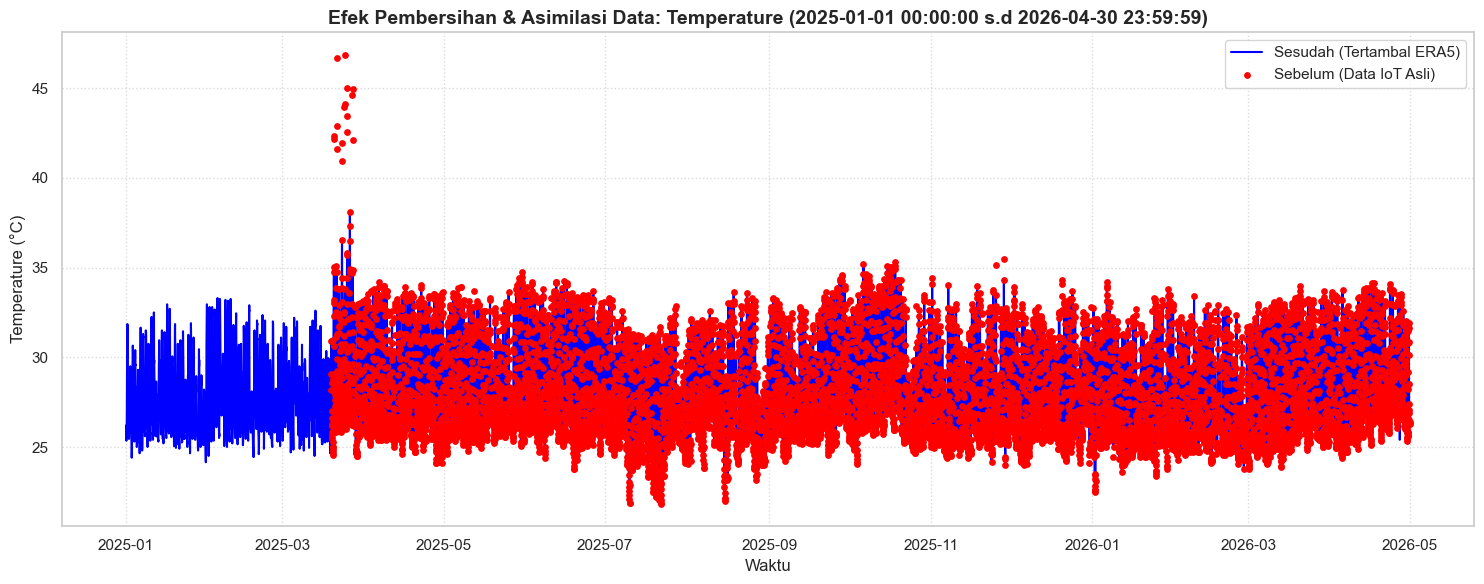

In [95]:
# 1. Tentukan batas waktu mutlak Anda
start_global = '2025-01-01 00:00:00'
end_global = '2026-04-30 23:59:59'

# 2. Eksekusi fungsi dengan memasukkan data IoT, ERA5, dan batas waktu
df_raw_05, df_clean_05 = bersihkan_data_hourly_hibrida(df_hourly, df_era5, start_global, end_global)

# 3. Plot hasilnya
plot_sebelum_sesudah(df_raw_05, df_clean_05, 'temperature', '°C', start_global, end_global)


📊 MEMUAT KOMPARASI TRANSPARANSI DATA: 2025-03-01 00:00:00 s.d 2025-03-31 23:59:59


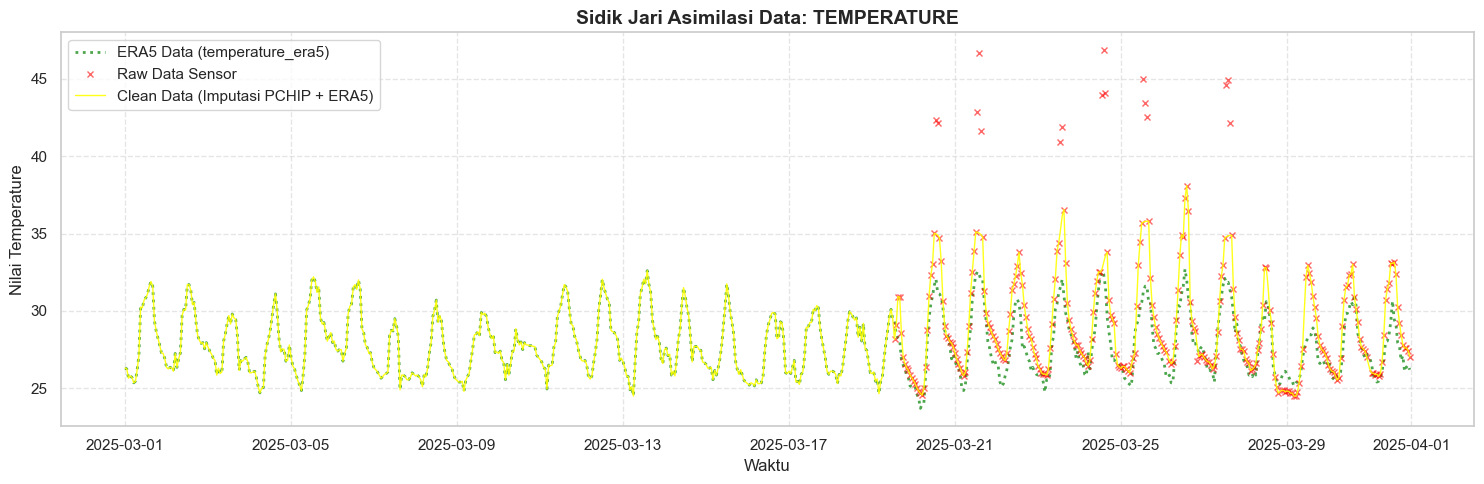

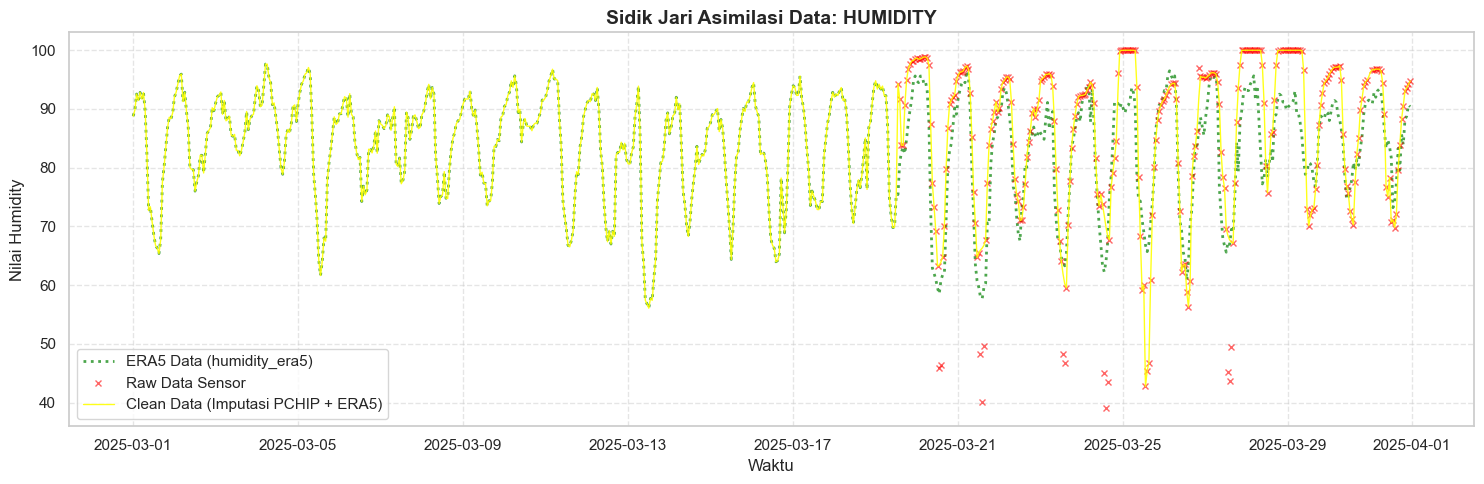

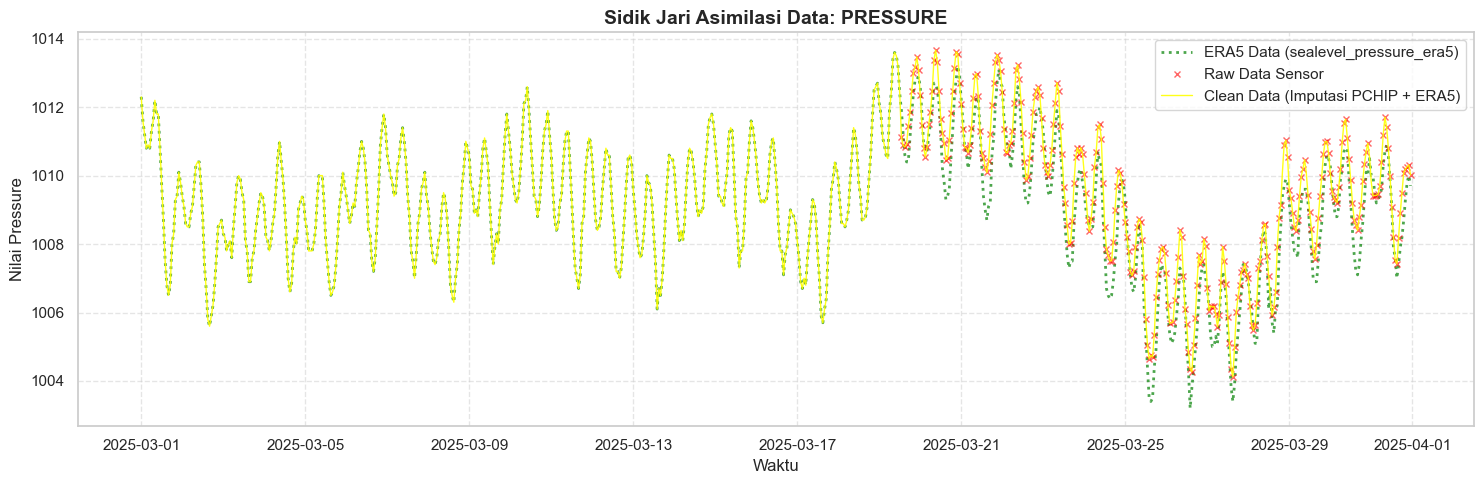

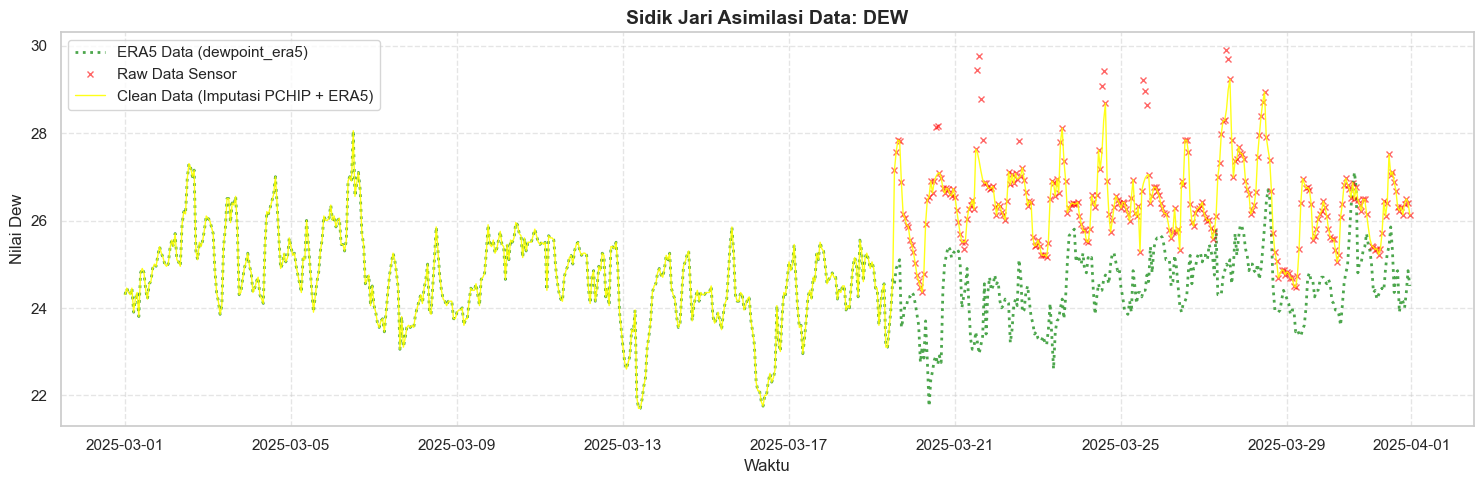

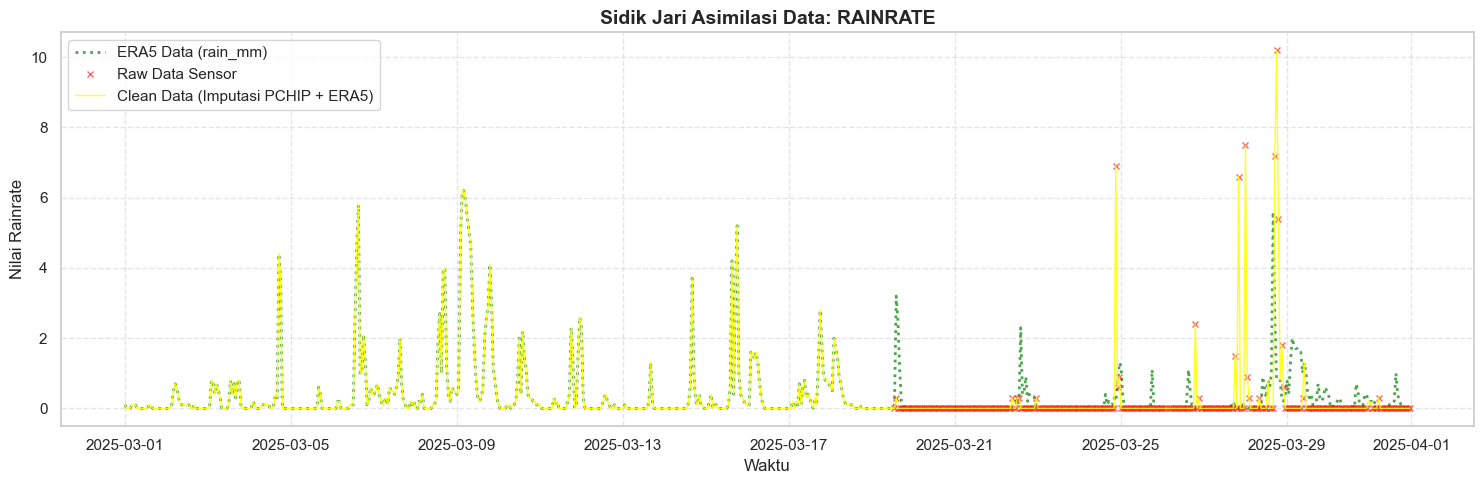

In [96]:
start_uji = '2025-03-01 00:00:00'
end_uji = '2025-03-31 23:59:59'

plot_komparasi(df_raw_05, df_clean_05, df_era5, era5_mapping, start_uji, end_uji)

🔍 MENGHITUNG MATRIKS KORELASI UNTUK: RAINRATE
⚠️ Fakta Lapangan: Data IoT Mentah Anda kosong sebanyak 16.31% pada rentang ini.


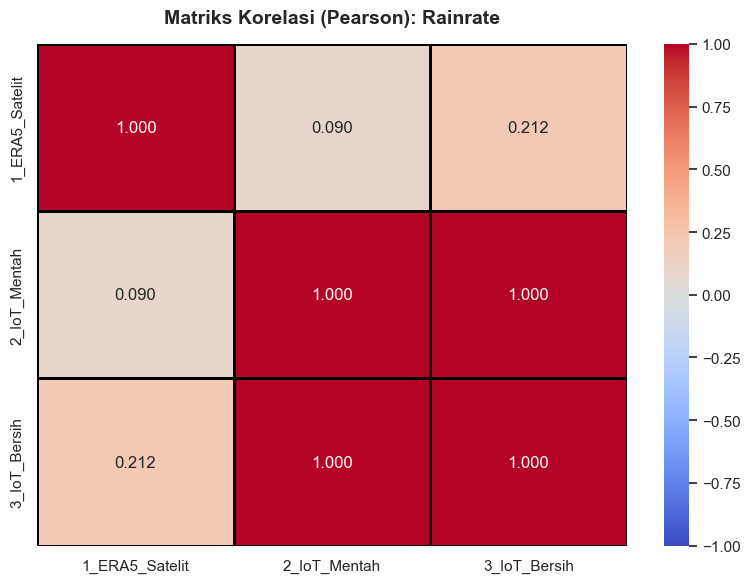

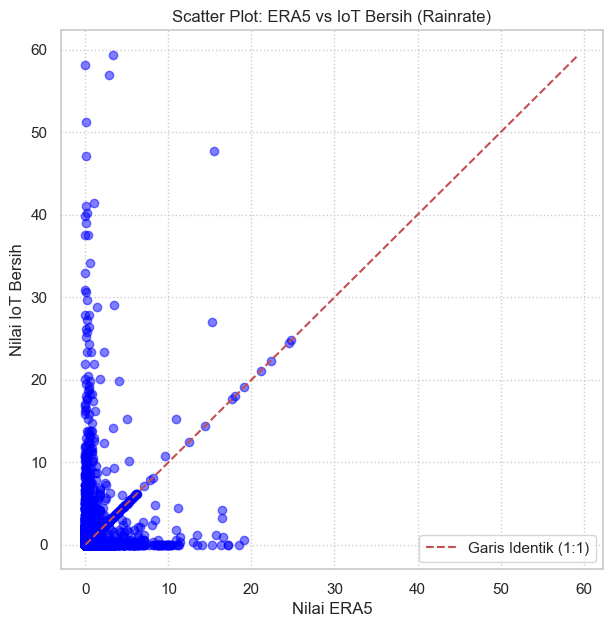

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cek_korelasi_transparansi(df_raw, df_clean, df_era5, era5_mapping, variabel='temperature'):
    """
    Membuat Matriks Korelasi (Heatmap) untuk membuktikan apakah 
    data IoT Bersih itu hasil jiplakan 100% dari ERA5 atau bukan.
    """
    print(f"🔍 MENGHITUNG MATRIKS KORELASI UNTUK: {variabel.upper()}")
    
    # Siapkan DataFrame arena pertarungan
    df_korelasi = pd.DataFrame(index=df_clean.index)
    
    # 1. Masukkan data ERA5 (Satelit)
    col_era5 = era5_mapping.get(variabel)
    if not col_era5 and variabel == 'rainrate':
        col_era5 = era5_mapping.get('rainrate', 'rain_mm')
        
    if col_era5 and col_era5 in df_era5.columns:
        # Menyamakan index ERA5 ke master index untuk amannya
        df_korelasi['1_ERA5_Satelit'] = df_era5[col_era5].reindex(df_clean.index)
        
    # 2. Masukkan data IoT Mentah (Kotor)
    if variabel in df_raw.columns:
        df_korelasi['2_IoT_Mentah'] = df_raw[variabel]
        
    # 3. Masukkan data IoT Bersih (Imputasi)
    if variabel in df_clean.columns:
        df_korelasi['3_IoT_Bersih'] = df_clean[variabel]
        
    # Tampilkan persentase NaN di IoT Mentah (Ini untuk membuktikan diagnosis kita!)
    persen_nan = df_korelasi['2_IoT_Mentah'].isnull().mean() * 100
    print(f"⚠️ Fakta Lapangan: Data IoT Mentah Anda kosong sebanyak {persen_nan:.2f}% pada rentang ini.")
    
    # Hitung Korelasi Pearson
    corr_matrix = df_korelasi.corr()
    
    # --- VISUALISASI HEATMAP ---
    plt.figure(figsize=(8, 6))
    
    # Buat Heatmap
    sns.heatmap(corr_matrix, 
                annot=True,          # Tampilkan angka di dalam kotak
                cmap='coolwarm',     # Warna merah (korelasi 1) ke biru (korelasi -1)
                vmin=-1, vmax=1,     # Batas nilai korelasi
                fmt=".3f",           # Tampilkan 3 angka di belakang koma
                linewidths=1, 
                linecolor='black')
    
    plt.title(f'Matriks Korelasi (Pearson): {variabel.capitalize()}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    # --- VISUALISASI SCATTER PLOT (Opsional tapi mematikan) ---
    # Untuk melihat sebaran data secara langsung
    plt.figure(figsize=(7, 7))
    plt.scatter(df_korelasi['1_ERA5_Satelit'], df_korelasi['3_IoT_Bersih'], alpha=0.5, color='blue')
    
    # Garis diagonal 1:1 (Jika titik-titik membentuk garis lurus ini, berarti datanya 100% jiplak/identik)
    max_val = max(df_korelasi['1_ERA5_Satelit'].max(), df_korelasi['3_IoT_Bersih'].max())
    min_val = min(df_korelasi['1_ERA5_Satelit'].min(), df_korelasi['3_IoT_Bersih'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Garis Identik (1:1)')
    
    plt.title(f'Scatter Plot: ERA5 vs IoT Bersih ({variabel.capitalize()})')
    plt.xlabel('Nilai ERA5')
    plt.ylabel('Nilai IoT Bersih')
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()

# ==============================================================================
# CARA EKSEKUSI
# ==============================================================================
# Coba jalankan untuk rainrate atau temperature
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='rainrate')